Solution of Poisson's Equation
$
\begin{align}
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x, y)
\end{align}
$

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [4]:
x = np.linspace(0, 3, 4)
y = np.linspace(0, 3, 4)
X, Y = np.meshgrid(x, y)


u = np.zeros((4, 4), float)

# Bottom boundary: y=0, x>0
u[0, 1:] = 5 * x[1:]

# Top boundary: y=3, x<3
u[-1, :-1] = x[:-1]**3

# Left boundary: x=0, y<3
u[:-1, 0] = 10 + 2*y[:-1]

# Right boundary: x=3, y>0
u[1:, -1] = 20 + y[1:]

print(u)



[[10.  5. 10. 15.]
 [12.  0.  0. 21.]
 [14.  0.  0. 22.]
 [ 0.  1.  8. 23.]]


In [41]:
# No interior solve yet: only boundary values
print("Boundary values for u on the square domain:")
print("bottom y=0 :", u[0, :])
print("top    y=1 :", u[-1, :])
print("left   x=0 :", u[:, 0])
print("right  x=1 :", u[:, -1])

Boundary values for u on the square domain:
bottom y=0 : [10.  5. 10. 15.]
top    y=1 : [ 0.  1.  8. 23.]
left   x=0 : [10. 12. 14.  0.]
right  x=1 : [15. 21. 22. 23.]


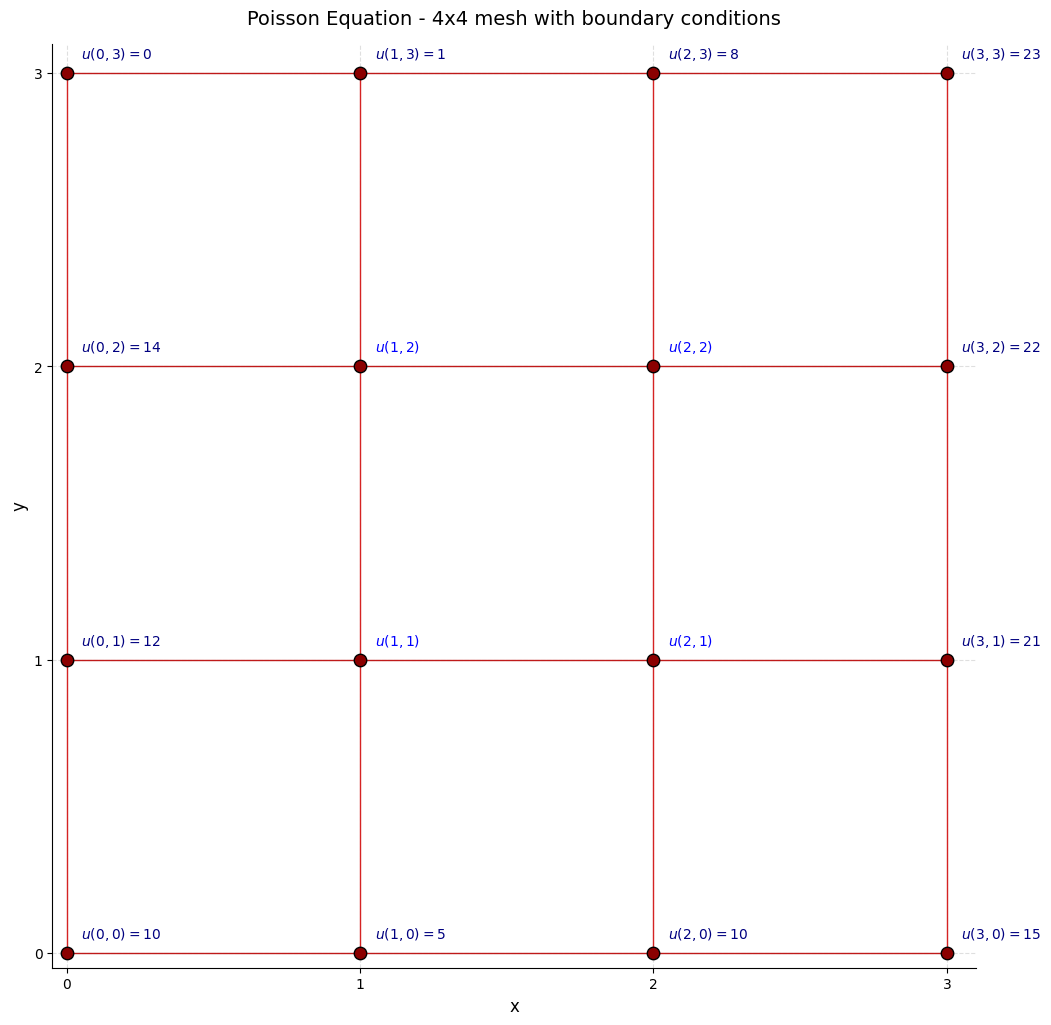

u array (rows=y, cols=x):
 [[10.  5. 10. 15.]
 [12.  0.  0. 21.]
 [14.  0.  0. 22.]
 [ 0.  1.  8. 23.]]


In [25]:
plt.figure(figsize=(12, 12))

# draw grid lines
for xi in x:
    plt.plot([xi]*len(y), y, color="#D52323", lw=1)
for yi in y:
    plt.plot(x, [yi]*len(x), color="#BF1A1A", lw=1)

# scatter points
plt.scatter(X, Y, c='darkred', s=80, edgecolor='k', zorder=5)

# annotate nodes
for j in range(4):      # row index = y
    for i in range(4):  # col index = x
        if i in [0, 3] or j in [0, 3]:
            # boundary nodes with values
            plt.text(X[j,i]+0.05, Y[j,i]+0.05,
                     f'$u({i},{j})={u[j,i]:.0f}$',
                     color='navy', fontsize=10, weight='bold')
        else:
            # interior nodes
            plt.text(X[j,i]+0.05, Y[j,i]+0.05,
                     f'$u({i},{j})$',
                     color='blue', fontsize=10, weight='bold')

plt.title('Poisson Equation - 4x4 mesh with boundary conditions', fontsize=14, pad=14)
plt.xlabel('x', fontsize=12); plt.ylabel('y', fontsize=12)
plt.axis('square')
plt.xlim(-0.05, 3.1); plt.ylim(-0.05, 3.1)
plt.xticks([0, 1, 2, 3], ['0', '1', '2', '3'])
plt.yticks([0, 1, 2, 3], ['0', '1', '2', '3'])

for k in ['top','right']:
    plt.gca().spines[k].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("u array (rows=y, cols=x):\n", u)


In [21]:
h = 1
def f(i, j):
    x = i*h
    y = j*h
    return 8 * (5*x**2 + y - 5)

In [24]:
u_cal = u.copy()
max_iterations = 100
tolerance = 1e-4

for iteration in range(max_iterations):
    u_old = u_cal.copy()
    for i in range(1, 3):
        for j in range(1, 3):
            u_cal[i, j] = 0.25*(u_old[i+1, j] + u_old[i-1, j] + u_old[i, j+1] + u_old[i, j-1] - h**2*f(i, j))
    
    # Preserve boundary values
    u_cal[0, :] = u[0, :]
    u_cal[-1, :] = u[-1, :]
    u_cal[:, 0] = u[:, 0]
    u_cal[:, -1] = u[:, -1]
    
    # Check for convergence
    error = np.max(np.abs(u_cal - u_old))
    if error < tolerance:
        print(f"Converged after {iteration + 1} iterations")
        break

print(u_cal)

Converged after 18 iterations
[[ 10.           5.          10.          15.        ]
 [ 12.          -9.95824051  -8.41657352  21.        ]
 [ 14.         -40.41657352 -38.70824051  22.        ]
 [  0.           1.           8.          23.        ]]
